# Fashion-MNIST CNN Classification

### Task 1

# Import Libraries

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

# Set Random Seeds

In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

# Load Dataset

In [ ]:
(train_images, train_labels), (test_images, test_labels) = \
    tf.keras.datasets.fashion_mnist.load_data()
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

print("Training Images Shape:", train_images.shape)
print("Training Labels Shape:", train_labels.shape)
print("Test Images Shape:", test_images.shape)
print("Test Labels Shape:", test_labels.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Images Shape: (60000, 28, 28)
Training Labels Shape: (60000,)
Test Images Shape: (10000, 28, 28)
Test Labels Shape: (10000,)


# Normalize Images

In [ ]:
train_images = train_images.astype("float32") / 255.0
test_images = test_images.astype("float32") / 255.0

# Reshape for CNN

In [ ]:
train_images = train_images.reshape(-1, 28, 28, 1)
test_images = test_images.reshape(-1, 28, 28, 1)

print("\nAfter Reshaping:")
print("Train Shape:", train_images.shape)
print("Test Shape:", test_images.shape)


After Reshaping:
Train Shape: (60000, 28, 28, 1)
Test Shape: (10000, 28, 28, 1)


# VISUALIZE SAMPLE IMAGES

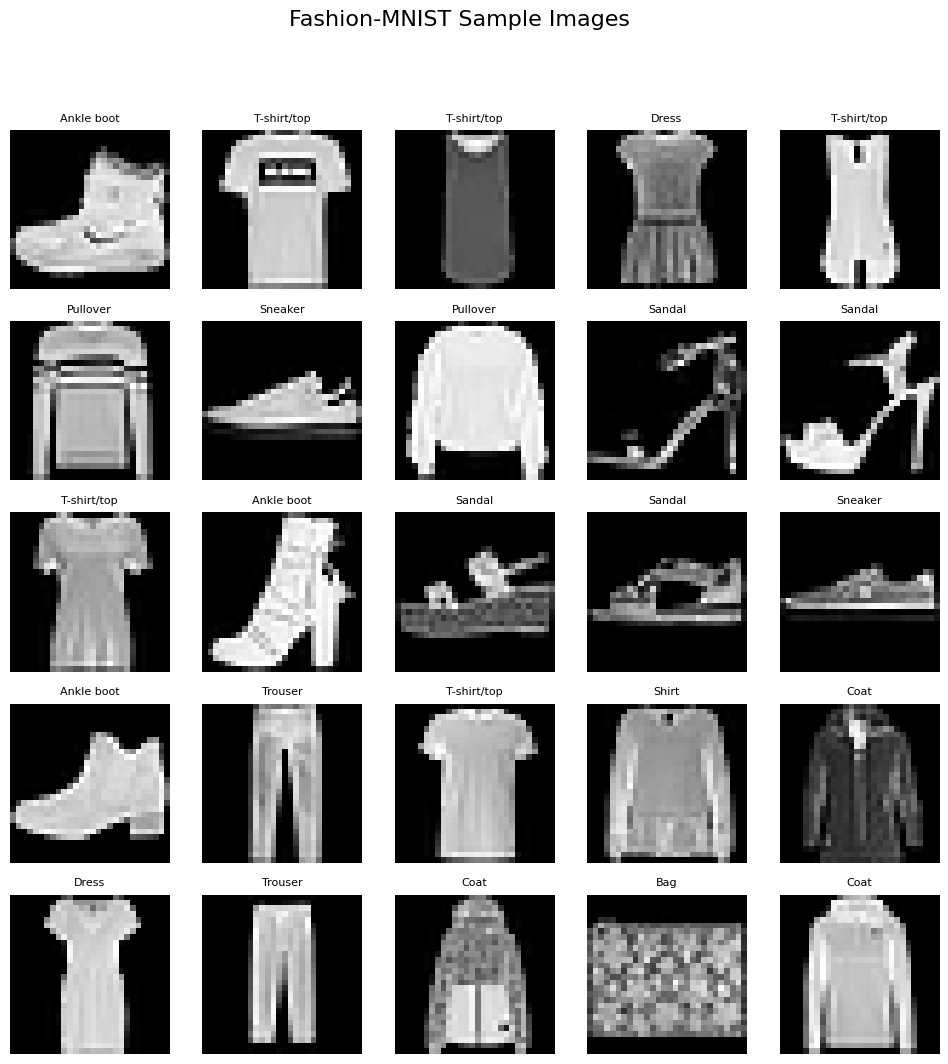

In [ ]:
plt.figure(figsize=(12,12))

for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(train_images[i].squeeze(), cmap='gray')
    plt.title(class_names[train_labels[i]], fontsize=8)
    plt.axis('off')

plt.suptitle("Fashion-MNIST Sample Images", fontsize=16)
plt.show()

# TASK 2: BUILD CNN MODEL

In [ ]:
model = models.Sequential([

    # First Convolution Block
    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same',
        input_shape=(28,28,1)
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D((2,2)),

      # Second Convolution Block
    layers.Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same'
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D((2,2)),

     # Third Convolution Block
    layers.Conv2D(
        128,
        (3,3),
        activation='relu',
        padding='same'
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D((2,2)),

      # Dense Layers
    layers.Flatten(),

    layers.Dense(
        128,
        activation='relu'
    ),

    layers.Dropout(0.4),

    layers.Dense(
        10,
        activation='softmax'
    )
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# COMPILE MODEL

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nMODEL SUMMARY\n")
model.summary()


MODEL SUMMARY



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,442 (947.04 KB)

 Trainable params: 241,994 (945.29 KB)

 Non-trainable params: 448 (1.75 KB)

# CALLBACKS

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_fashion_mnist_model.keras",
    monitor='val_accuracy',
    save_best_only=True
)

# TASK 3: TRAIN MODEL

In [ ]:
history = model.fit(
    train_images,
    train_labels,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 117s 150ms/step - accuracy: 0.8244 - loss: 0.4950 - val_accuracy: 0.8780 - val_loss: 0.3245
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 140s 147ms/step - accuracy: 0.8859 - loss: 0.3174 - val_accuracy: 0.8980 - val_loss: 0.2736
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 165s 178ms/step - accuracy: 0.9010 - loss: 0.2716 - val_accuracy: 0.8991 - val_loss: 0.2775
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 123s 164ms/step - accuracy: 0.9131 - loss: 0.2387 - val_accuracy: 0.9154 - val_loss: 0.2366
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 136s 156ms/step - accuracy: 0.9209 - loss: 0.2167 - val_accuracy: 0.8956 - val_loss: 0.2715
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 106s 141ms/step - accuracy: 0.9267 - loss: 0.2001 - val_accuracy: 0.9083 - val_loss: 0.2532
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 143s 142ms/step - accuracy: 0.9327 - loss: 0.1778 - val_accuracy: 0.9167 - val_loss: 0.2281
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 145s 147ms/step - accuracy: 0.9381 -

# PLOT TRAINING HISTORY

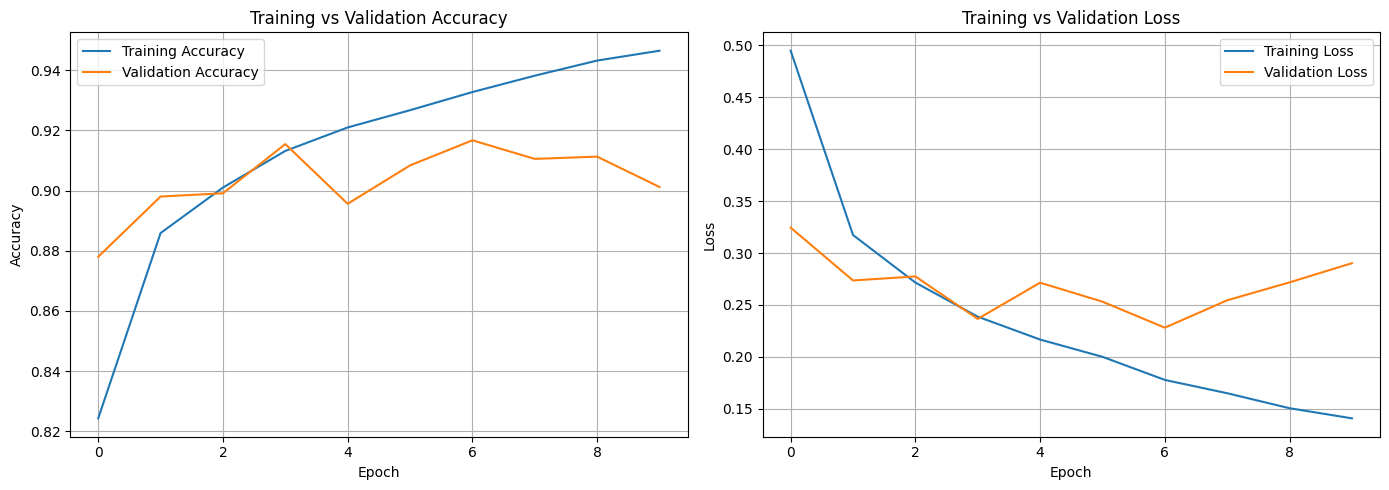

In [ ]:
plt.figure(figsize=(14,5))

# Accuracy Plot
plt.subplot(1,2,1)

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

# Loss Plot
plt.subplot(1,2,2)

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# TASK 4: MODEL EVALUATION

In [ ]:
test_loss, test_accuracy = model.evaluate(
    test_images,
    test_labels,
    verbose=2
)

print("\n==============================")
print("MODEL PERFORMANCE")
print("==============================")

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

313/313 - 6s - 18ms/step - accuracy: 0.9099 - loss: 0.2527

MODEL PERFORMANCE
Test Loss: 0.2527
Test Accuracy: 0.9099


# PREDICTIONS

In [ ]:
predictions = model.predict(test_images)

predicted_labels = np.argmax(
    predictions,
    axis=1
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step


# CONFUSION MATRIX

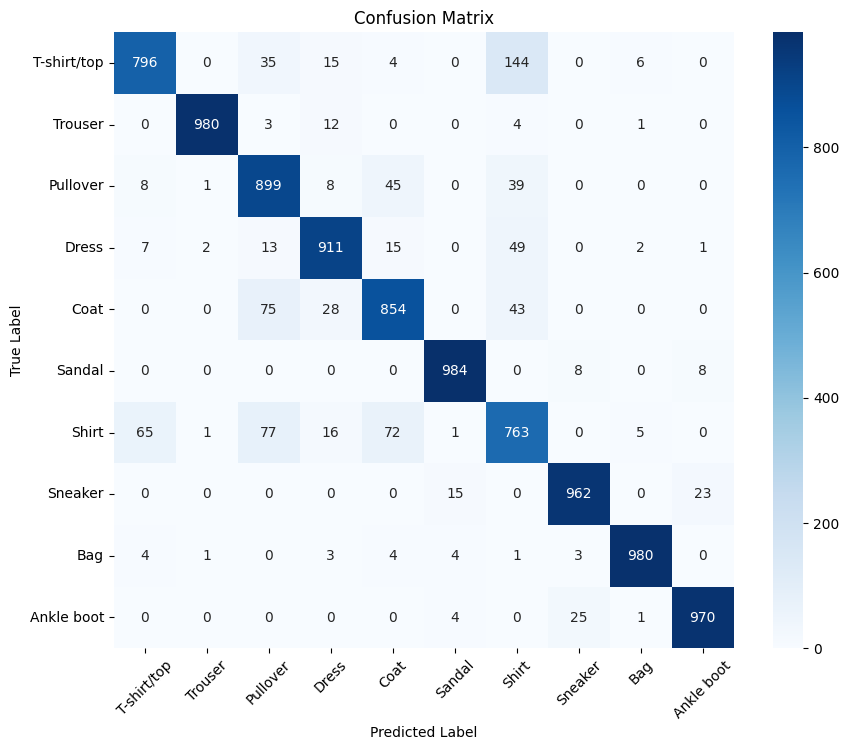

In [ ]:
cm = confusion_matrix(
    test_labels,
    predicted_labels
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

# CLASSIFICATION REPORT

In [ ]:
print("\nCLASSIFICATION REPORT\n")

print(
    classification_report(
        test_labels,
        predicted_labels,
        target_names=class_names
    )
)


CLASSIFICATION REPORT

              precision    recall  f1-score   support

 T-shirt/top       0.90      0.80      0.85      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.82      0.90      0.86      1000
       Dress       0.92      0.91      0.91      1000
        Coat       0.86      0.85      0.86      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.73      0.76      0.75      1000
     Sneaker       0.96      0.96      0.96      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.97      0.97      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



# TASK 5: VISUALIZE PREDICTIONS

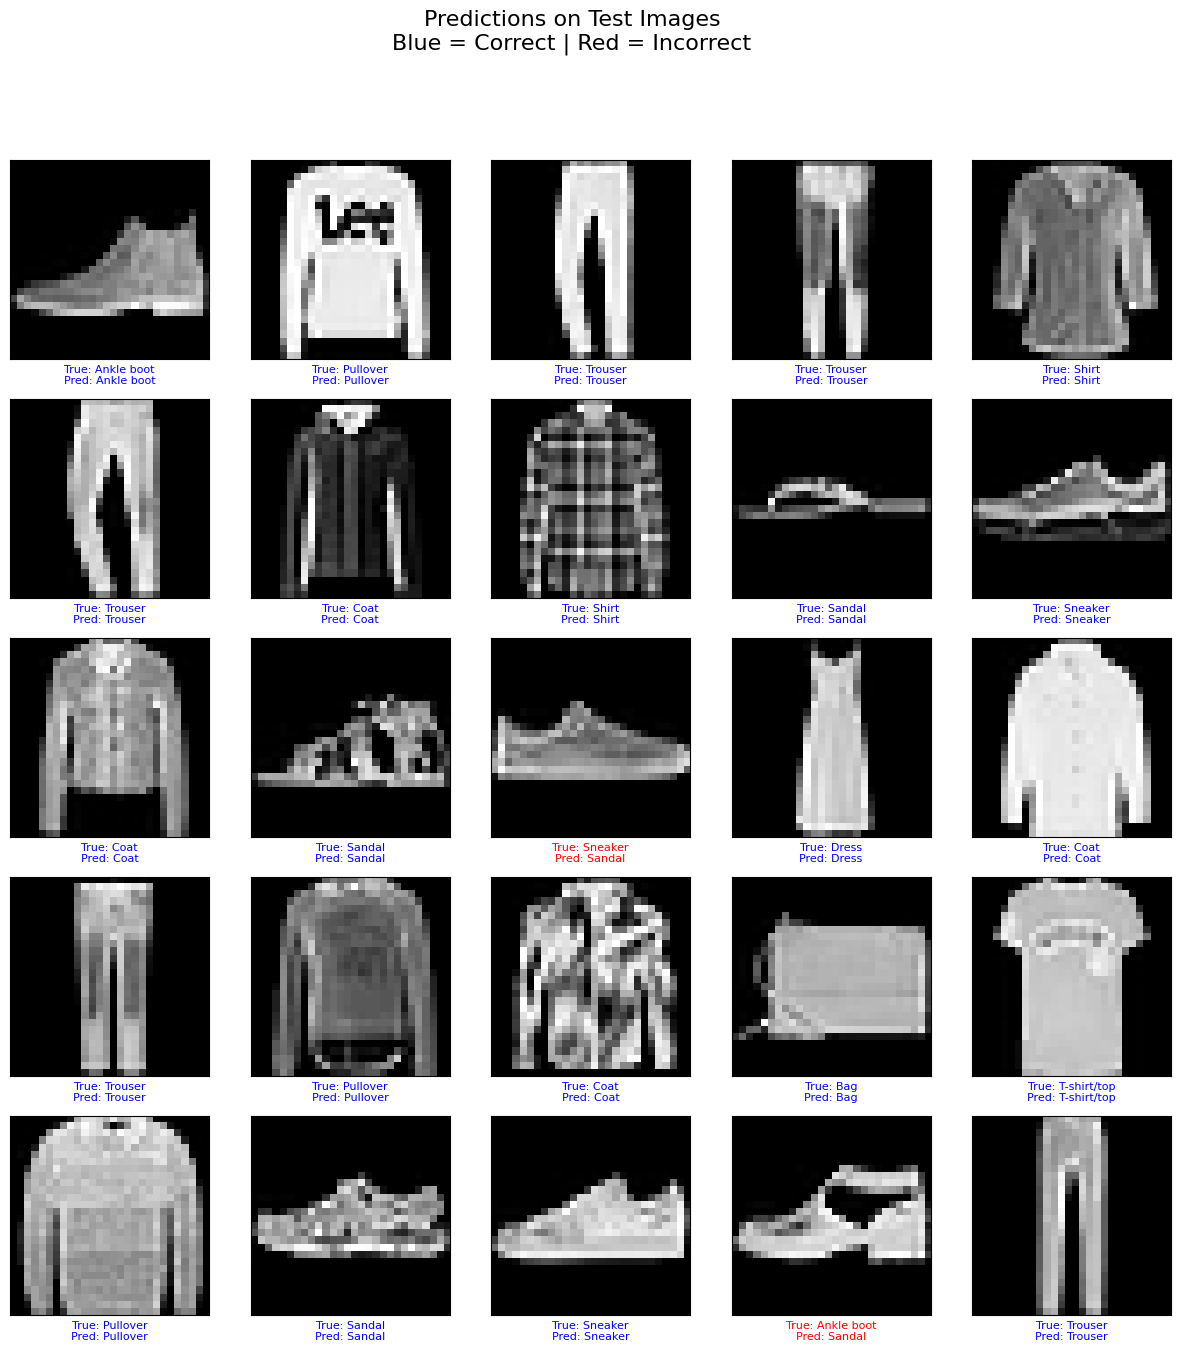

In [ ]:
plt.figure(figsize=(15,15))

for i in range(25):

    plt.subplot(5,5,i+1)

    plt.imshow(
        test_images[i].reshape(28,28),
        cmap='gray'
    )

    true_label = class_names[test_labels[i]]
    pred_label = class_names[predicted_labels[i]]

    color = "blue" if true_label == pred_label else "red"

    plt.xlabel(
        f"True: {true_label}\nPred: {pred_label}",
        color=color,
        fontsize=8
    )

    plt.xticks([])
    plt.yticks([])

plt.suptitle(
    "Predictions on Test Images\nBlue = Correct | Red = Incorrect",
    fontsize=16
)

plt.show()

# BONUS: SHOW MISCLASSIFIED IMAGES

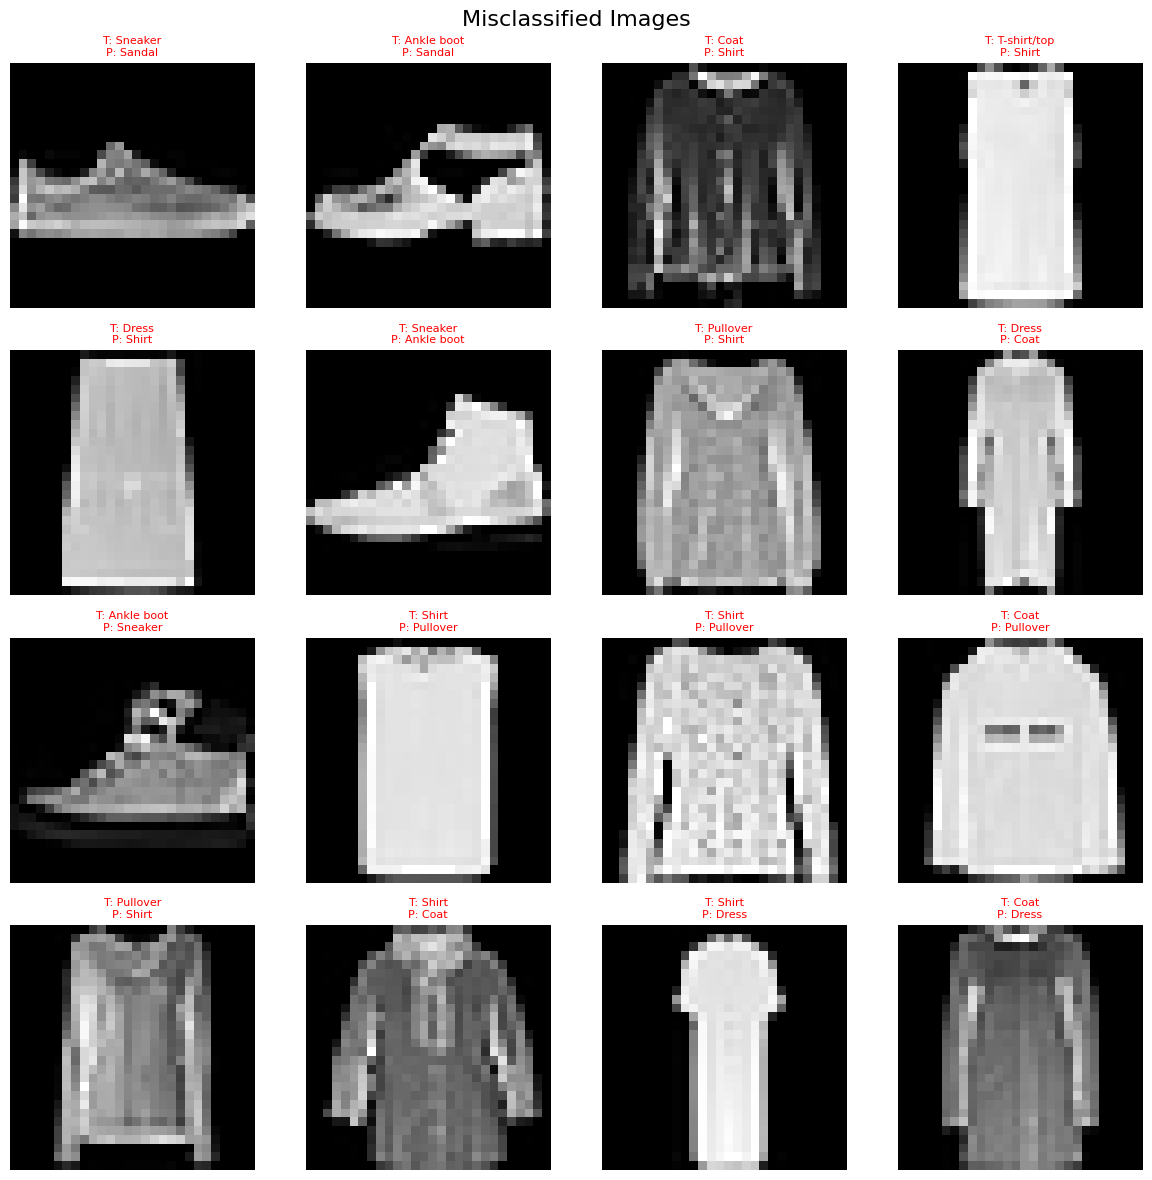

In [ ]:
misclassified = np.where(
    predicted_labels != test_labels
)[0]

plt.figure(figsize=(12,12))

for i, index in enumerate(misclassified[:16]):

    plt.subplot(4,4,i+1)

    plt.imshow(
        test_images[index].reshape(28,28),
        cmap='gray'
    )

    plt.title(
        f"T: {class_names[test_labels[index]]}\n"
        f"P: {class_names[predicted_labels[index]]}",
        fontsize=8,
        color='red'
    )

    plt.axis('off')

plt.suptitle(
    "Misclassified Images",
    fontsize=16
)

plt.show()

# FINAL CONCLUSION

In [ ]:
print("\nCONCLUSION")
print("-"*50)

print(
    f"The improved CNN achieved "
    f"{test_accuracy*100:.2f}% test accuracy."
)

print(
    "Batch Normalization improved training stability, "
    "while Dropout helped reduce overfitting."
)


print(
    "Most classification errors occur between visually "
    "similar categories such as Shirt, Coat, "
    "Pullover, and T-shirt/top."
)

print(
    "Overall, the CNN performed very well on the "
    "Fashion-MNIST dataset."
)


CONCLUSION
--------------------------------------------------
The improved CNN achieved 90.99% test accuracy.
Batch Normalization improved training stability, while Dropout helped reduce overfitting.
Most classification errors occur between visually similar categories such as Shirt, Coat, Pullover, and T-shirt/top.
Overall, the CNN performed very well on the Fashion-MNIST dataset.
